# Problems Notebook

## Problem 1: Extending the Lady Tasting Tea.

> Let's extend the Lady Tasting Tea experiment as follows. The original experiment has 8 cups: 4 tea-first and 4 milk-first. Suppose we prepare 12 cups: 8 tea-first and 4 milk-first. A participant claims they can tell which was poured first.<br><br>
>Simulate this experiment using numpy by randomly shuffling the cups many times and calculating the probability of the participant correctly identifying all cups by chance. Compare your result with the original 8-cup experiment.<br><br>
>In your notebook, explain your simulation process clearly, report and interpret the estimated probability, and discuss whether, based on this probability, you would consider extending or relaxing the p-value threshold compared to the original design.



In [10]:
# Mathematical functions from the standard library.
# https://docs.python.org/3/library/math.html
import math

# Permutations and combinations.
# https://docs.python.org/3/library/itertools.html
import itertools

# Random selections.
# https://docs.python.org/3/library/random.html
import random

# Numerical structures and operations.
# https://numpy.org/doc/stable/reference/index.html#reference
import numpy as np

# Plotting.
# https://matplotlib.org/stable/contents.html
import matplotlib.pyplot as plt

## Cups of Tea

In [11]:
# Number of cups of tea in total.
no_cups = 12

# Number of cups of tea with milk in first.
no_cups_milk_first = 4

# Number of cups of tea with tea in first.
no_cups_tea_first = 8

## Combinations of choosing 4 cups from 12

Use [math.comb(n, k)](https://docs.python.org/3/library/math.html#math.comb) to calculate the number of ways of choosing **k** elements from a set of size **n**, where the order of the chosen elements does not matter, and every element can only be selected once.


In [12]:
# No of ways of choosing 4 cups from 12.
import math

# math.comb(n,k) gives the number of ways of choosing k elements from a set of size n, where the order of the chosen elements does not matter, 
# and every element can only be selected once.                                     
no_ways = math.comb(no_cups, no_cups_milk_first)

no_ways

495

## How math.comb(n,k) works

In [13]:
# Total number of ways of selecting four cups from twelve, keeping them in order.
ways_ordered = 12 * 11 * 10 * 9

# Show.
ways_ordered

11880

Note we don't care about order: if cups `2`, `4`, `5`, and `8` are selected in order it is the same result as if `2`, `8`, `4`, and `5` were selected, or any other permutation.

`4 8 6 5`

`8 6 4 5`

`_ _ _ _`

In [14]:
# No of ways of shuffling four cups.
no_shuffles = 4 * 3 * 2 * 1

# Show.
no_shuffles

24

In [15]:
# No of combinations.
no_combs = ways_ordered // no_shuffles

# Show.
no_combs

495

In [16]:
#Give each cup a label from 0 to 11. Note that this is just a label, and no ordering is implicit.
# The cups are not arranged in a line or circle. They are just a set of cups.
labels = list(range(no_cups))
labels

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

In [17]:
# All possible combinations of 4 cups from 12. There are 495 such combinations (see above).
# Each combination is a tuple of 4 labels.
# The order of the labels in each tuple does not matter, and the order of the tuples in the list does not matter.
# We use itertools.combinations to generate the combinations.
# https://docs.python.org/3/library/itertools.html#itertools.combinations
combs = list(itertools.combinations(labels, no_cups_milk_first))

# Show.
combs

[(0, 1, 2, 3),
 (0, 1, 2, 4),
 (0, 1, 2, 5),
 (0, 1, 2, 6),
 (0, 1, 2, 7),
 (0, 1, 2, 8),
 (0, 1, 2, 9),
 (0, 1, 2, 10),
 (0, 1, 2, 11),
 (0, 1, 3, 4),
 (0, 1, 3, 5),
 (0, 1, 3, 6),
 (0, 1, 3, 7),
 (0, 1, 3, 8),
 (0, 1, 3, 9),
 (0, 1, 3, 10),
 (0, 1, 3, 11),
 (0, 1, 4, 5),
 (0, 1, 4, 6),
 (0, 1, 4, 7),
 (0, 1, 4, 8),
 (0, 1, 4, 9),
 (0, 1, 4, 10),
 (0, 1, 4, 11),
 (0, 1, 5, 6),
 (0, 1, 5, 7),
 (0, 1, 5, 8),
 (0, 1, 5, 9),
 (0, 1, 5, 10),
 (0, 1, 5, 11),
 (0, 1, 6, 7),
 (0, 1, 6, 8),
 (0, 1, 6, 9),
 (0, 1, 6, 10),
 (0, 1, 6, 11),
 (0, 1, 7, 8),
 (0, 1, 7, 9),
 (0, 1, 7, 10),
 (0, 1, 7, 11),
 (0, 1, 8, 9),
 (0, 1, 8, 10),
 (0, 1, 8, 11),
 (0, 1, 9, 10),
 (0, 1, 9, 11),
 (0, 1, 10, 11),
 (0, 2, 3, 4),
 (0, 2, 3, 5),
 (0, 2, 3, 6),
 (0, 2, 3, 7),
 (0, 2, 3, 8),
 (0, 2, 3, 9),
 (0, 2, 3, 10),
 (0, 2, 3, 11),
 (0, 2, 4, 5),
 (0, 2, 4, 6),
 (0, 2, 4, 7),
 (0, 2, 4, 8),
 (0, 2, 4, 9),
 (0, 2, 4, 10),
 (0, 2, 4, 11),
 (0, 2, 5, 6),
 (0, 2, 5, 7),
 (0, 2, 5, 8),
 (0, 2, 5, 9),
 (0, 2, 5, 10),
 (

In [18]:
# Select four cups at random to put milk in first.
# https://docs.python.org/3/library/random.html#random.sample
labels_milk = random.sample(labels, 4)

# Sort, inplace.
labels_milk.sort()

# Show.
labels_milk

[5, 6, 7, 10]

In [19]:
# Turn labels_milk into a set.
# Uses: https://docs.python.org/3/tutorial/datastructures.html#sets
set(labels_milk)

{5, 6, 7, 10}

In [20]:
# Calculate the overlap between each element of combs

no_overlaps = []

for comb in combs:
  # Turn comb into a set.
  s1 = set(comb)
  # Turn labels_milk into a set.
  s2 = set(labels_milk)
  # Figure out where they overlap.
  overlap = s1.intersection(s2)
  # Show the combination and the overlap.
  print(comb, overlap, len(overlap))
  # Append overlap to no_overlaps.
  no_overlaps.append(len(overlap))

(0, 1, 2, 3) set() 0
(0, 1, 2, 4) set() 0
(0, 1, 2, 5) {5} 1
(0, 1, 2, 6) {6} 1
(0, 1, 2, 7) {7} 1
(0, 1, 2, 8) set() 0
(0, 1, 2, 9) set() 0
(0, 1, 2, 10) {10} 1
(0, 1, 2, 11) set() 0
(0, 1, 3, 4) set() 0
(0, 1, 3, 5) {5} 1
(0, 1, 3, 6) {6} 1
(0, 1, 3, 7) {7} 1
(0, 1, 3, 8) set() 0
(0, 1, 3, 9) set() 0
(0, 1, 3, 10) {10} 1
(0, 1, 3, 11) set() 0
(0, 1, 4, 5) {5} 1
(0, 1, 4, 6) {6} 1
(0, 1, 4, 7) {7} 1
(0, 1, 4, 8) set() 0
(0, 1, 4, 9) set() 0
(0, 1, 4, 10) {10} 1
(0, 1, 4, 11) set() 0
(0, 1, 5, 6) {5, 6} 2
(0, 1, 5, 7) {5, 7} 2
(0, 1, 5, 8) {5} 1
(0, 1, 5, 9) {5} 1
(0, 1, 5, 10) {10, 5} 2
(0, 1, 5, 11) {5} 1
(0, 1, 6, 7) {6, 7} 2
(0, 1, 6, 8) {6} 1
(0, 1, 6, 9) {6} 1
(0, 1, 6, 10) {10, 6} 2
(0, 1, 6, 11) {6} 1
(0, 1, 7, 8) {7} 1
(0, 1, 7, 9) {7} 1
(0, 1, 7, 10) {10, 7} 2
(0, 1, 7, 11) {7} 1
(0, 1, 8, 9) set() 0
(0, 1, 8, 10) {10} 1
(0, 1, 8, 11) set() 0
(0, 1, 9, 10) {10} 1
(0, 1, 9, 11) set() 0
(0, 1, 10, 11) {10} 1
(0, 2, 3, 4) set() 0
(0, 2, 3, 5) {5} 1
(0, 2, 3, 6) {6} 1
(0, 2, 3, 7

In [21]:
# Count the number of times each overlap occurs.
counts = np.unique(no_overlaps, return_counts=True)

# Show.
counts

(array([0, 1, 2, 3, 4]), array([ 70, 224, 168,  32,   1], dtype=int64))

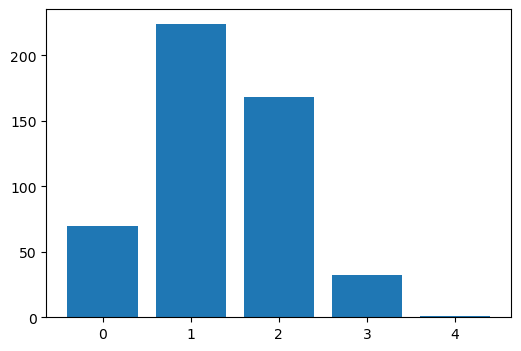

In [22]:
# Create a figure.
fig, ax = plt.subplots(figsize=(6, 4))

# Bar chart.
ax.bar(counts[0], counts[1]);

## The Null Hypothesis

- The lady has no special power to tell the difference between cups of tea with milk in first and cups of tea with tea in first.

- The lady is selecting the four cups from the eight cups at random.

# End